# Customer Segmentation & Campaign Effectiveness Analysis

## Business Problem

A retail company wants to better understand customer purchasing behavior and improve marketing campaign effectiveness through customer segmentation and data-driven insights.

In [1]:
!rm -rf customer-campaign-analysis

!git clone https://github.com/lla86/customer-campaign-analysis.git
%cd customer-campaign-analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/marketing_campaign.csv",
    sep="\t"
)

print(df.shape)
df.head()

Cloning into 'customer-campaign-analysis'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 16 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 65.41 KiB | 13.08 MiB/s, done.
/content/customer-campaign-analysis
(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Data Cleaning
Removed records with unrealistic birth years (before 1940) to improve data quality and avoid skewing age-related analysis.


In [3]:
df.isnull().sum().sort_values(ascending=False)

,0
Income,24
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [4]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [5]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

In [6]:
df = df.drop("ID", axis=1)


In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y"
)

In [9]:
df["Year_Birth"].sort_values().head(10)

,Year_Birth
239,1893
339,1899
192,1900
1950,1940
424,1941
1923,1943
415,1943
894,1943
39,1943
1150,1943


In [10]:
df = df[df["Year_Birth"] >= 1940]
print(df.shape)

(2237, 28)


Feature Engineering

In [11]:
# Age
df["Age"] = 2026 - df["Year_Birth"]

# Children
df["Children"] = df["Kidhome"] + df["Teenhome"]

# Total spending
df["Total_Spent"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

# Total purchases
df["Total_Purchases"] = (
    df["NumDealsPurchases"]
    + df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

# Total campaign acceptance
df["Total_Accepted"] = (
    df["AcceptedCmp1"]
    + df["AcceptedCmp2"]
    + df["AcceptedCmp3"]
    + df["AcceptedCmp4"]
    + df["AcceptedCmp5"]
    + df["Response"]
)


df[[
    "Age",
    "Children",
    "Total_Spent",
    "Total_Purchases",
    "Total_Accepted"
]].head()

,Age,Children,Total_Spent,Total_Purchases,Total_Accepted
0,69,0,1617,25,1
1,72,2,27,6,0
2,61,0,776,21,0
3,42,1,53,8,0
4,45,1,422,19,0


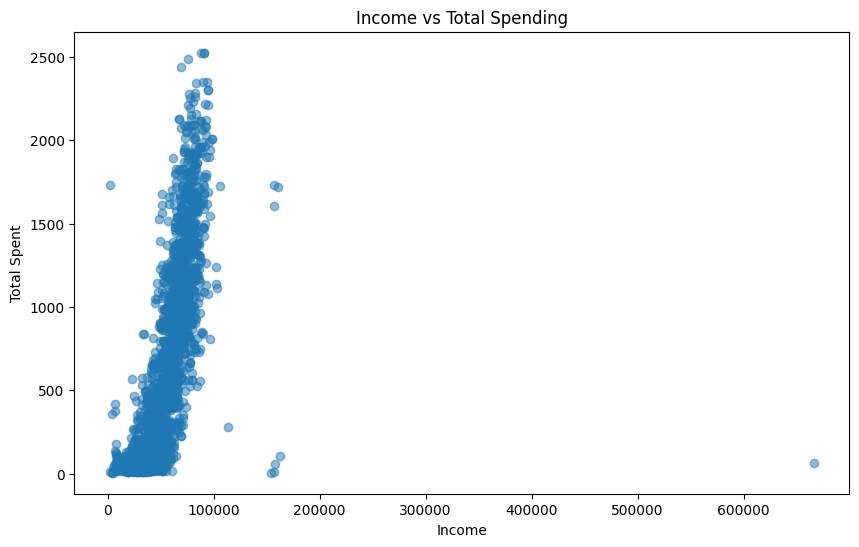

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Income"],
    df["Total_Spent"],
    alpha=0.5
)

plt.xlabel("Income")
plt.ylabel("Total Spent")
plt.title("Income vs Total Spending")

plt.show()

In [13]:
df["Income"].corr(df["Total_Spent"])


np.float64(0.6647068411041401)

In [14]:
df.groupby("Children")["Total_Spent"].mean()

,Total_Spent
Children,
0,1104.857143
1,473.495560
2,245.947743
3,274.603774


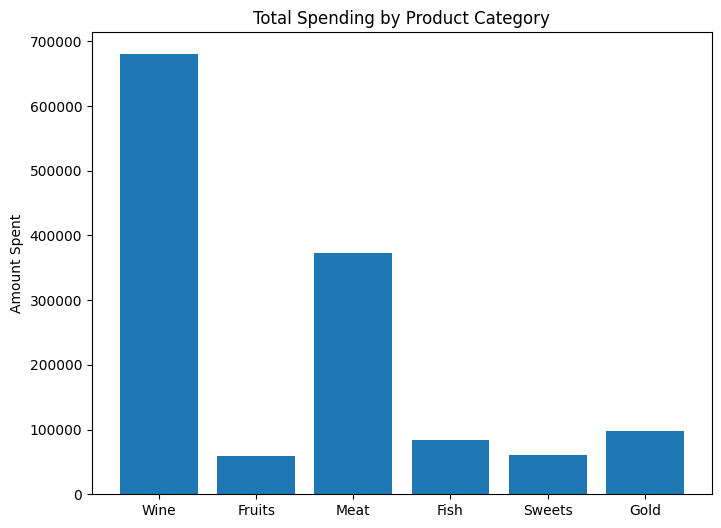

In [15]:
product_spending = {
    "Wine": df["MntWines"].sum(),
    "Fruits": df["MntFruits"].sum(),
    "Meat": df["MntMeatProducts"].sum(),
    "Fish": df["MntFishProducts"].sum(),
    "Sweets": df["MntSweetProducts"].sum(),
    "Gold": df["MntGoldProds"].sum()
}

plt.figure(figsize=(8,6))

plt.bar(
    product_spending.keys(),
    product_spending.values()
)

plt.title("Total Spending by Product Category")
plt.ylabel("Amount Spent")

plt.show()

In [16]:
campaign_rates = {
    "Cmp1": df["AcceptedCmp1"].mean(),
    "Cmp2": df["AcceptedCmp2"].mean(),
    "Cmp3": df["AcceptedCmp3"].mean(),
    "Cmp4": df["AcceptedCmp4"].mean(),
    "Cmp5": df["AcceptedCmp5"].mean(),
    "Latest": df["Response"].mean()
}

campaign_rates

{'Cmp1': np.float64(0.06437192668752793),
 'Cmp2': np.float64(0.013410818059901655),
 'Cmp3': np.float64(0.07286544479213232),
 'Cmp4': np.float64(0.07465355386678588),
 'Cmp5': np.float64(0.07241841752346893),
 'Latest': np.float64(0.14930710773357175)}

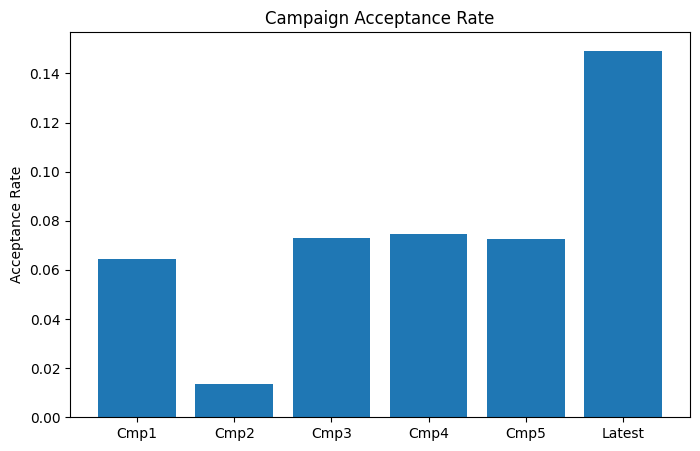

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    campaign_rates.keys(),
    campaign_rates.values()
)

plt.title("Campaign Acceptance Rate")
plt.ylabel("Acceptance Rate")

plt.show()

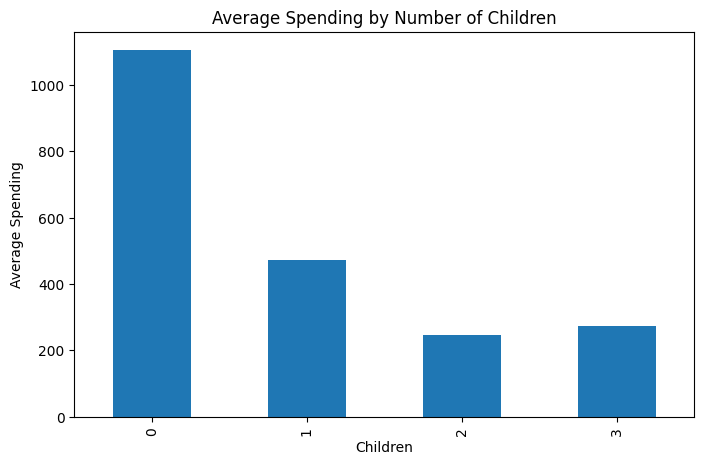

In [18]:
df.groupby("Children")["Total_Spent"].mean()
df.groupby("Children")["Total_Spent"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Spending by Number of Children")
plt.ylabel("Average Spending")

plt.show()

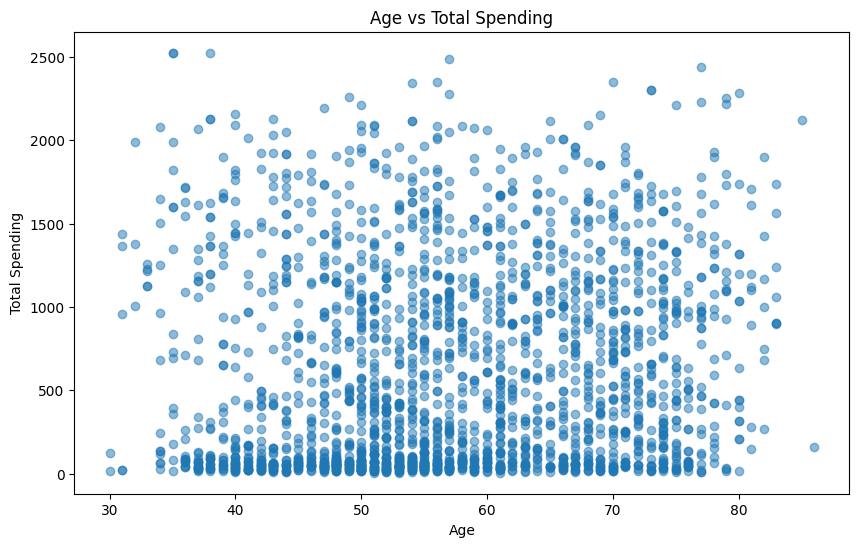

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Age"],
    df["Total_Spent"],
    alpha=0.5
)

plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.title("Age vs Total Spending")

plt.show()

In [20]:
df["Customer_Segment"] = pd.qcut(
    df["Total_Spent"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

In [21]:
df["Customer_Segment"].value_counts()

,count
Customer_Segment,
Low Value,746
High Value,746
Medium Value,745


In [22]:
segment_summary = df.groupby(
    "Customer_Segment"
).agg({
    "Income":"mean",
    "Age":"mean",
    "Total_Spent":"mean",
    "Total_Purchases":"mean",
    "Total_Accepted":"mean"
})

segment_summary

/tmp/ipykernel_1344/3046931617.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = df.groupby(


,Income,Age,Total_Spent,Total_Purchases,Total_Accepted
Customer_Segment,,,,,
Low Value,32962.629357,53.851206,51.239946,6.471850,0.156836
Medium Value,50839.973154,58.530201,412.975839,16.263087,0.291275
High Value,72877.760724,58.915550,1352.756032,21.879357,0.892761


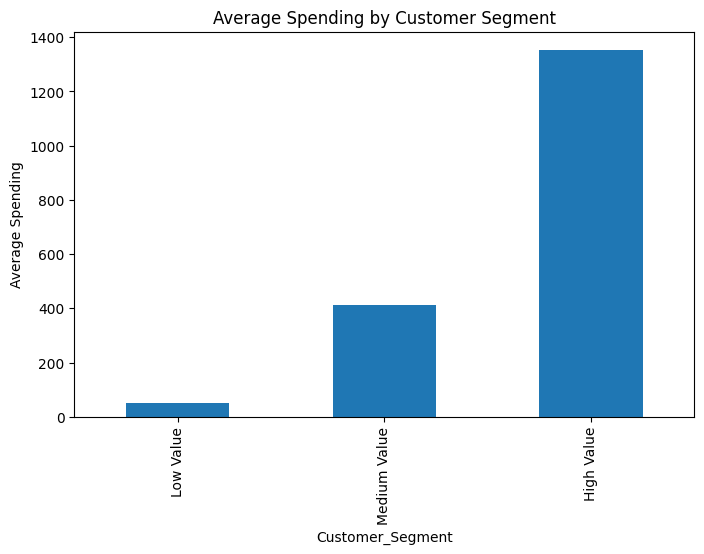

In [23]:
segment_summary["Total_Spent"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Spending by Customer Segment")
plt.ylabel("Average Spending")

plt.show()

# Business Insights & Recommendations

## Executive Summary

This analysis examined customer demographics, purchasing behavior, and marketing campaign performance using a dataset of over 2,200 customers. The objective was to identify high-value customer segments, understand the factors influencing spending behavior, and evaluate marketing campaign effectiveness.

The analysis revealed that customer income is strongly associated with spending behavior, customers without children represent the highest-value segment, and high-value customers are significantly more responsive to marketing campaigns. Additionally, the latest marketing campaign achieved substantially higher acceptance rates than previous campaigns, suggesting improvements in targeting strategy or campaign design.

These findings provide actionable opportunities to improve customer targeting, increase marketing return on investment (ROI), and strengthen customer retention efforts.

---

# Key Findings

## 1. Income is a Strong Predictor of Customer Spending

A correlation analysis between annual income and total customer spending produced a correlation coefficient of **0.665**, indicating a strong positive relationship.

### Observation

Customers with higher income levels consistently spend more across product categories.

### Business Impact

Income is one of the most important variables for identifying valuable customers and prioritizing marketing investments.

### Recommendation

* Develop premium marketing campaigns for higher-income customers.
* Offer personalized product recommendations and exclusive promotions to increase customer lifetime value.
* Use income as a key segmentation variable for future CRM initiatives.

---

## 2. Household Composition Significantly Influences Spending

Customer spending decreases substantially as the number of children in a household increases.

| Number of Children | Average Spending |
| ------------------ | ---------------- |
| 0                  | $1,104.86        |
| 1                  | $473.50          |
| 2                  | $245.95          |
| 3                  | $274.60          |

### Observation

Customers without children spend more than four times as much as customers with two children.

### Business Impact

Family responsibilities may reduce discretionary spending and change purchasing priorities.

### Recommendation

For customers without children:

* Promote premium products and luxury offerings.
* Increase loyalty and VIP program participation.

For customers with children:

* Introduce bundle promotions and family-oriented offers.
* Emphasize value-driven messaging and discounts.

---

## 3. The Latest Marketing Campaign Outperformed Previous Campaigns

Campaign acceptance rates varied significantly across historical campaigns.

| Campaign        | Acceptance Rate |
| --------------- | --------------- |
| Campaign 1      | 6.4%            |
| Campaign 2      | 1.3%            |
| Campaign 3      | 7.3%            |
| Campaign 4      | 7.5%            |
| Campaign 5      | 7.2%            |
| Latest Campaign | 14.9%           |

### Observation

The latest campaign achieved the highest acceptance rate and nearly doubled the performance of previous campaigns.

### Business Impact

Recent improvements in campaign design, targeting, channel selection, or promotional offers may have contributed to stronger customer engagement.

### Recommendation

* Investigate the audience targeting criteria used in the latest campaign.
* Analyze campaign messaging and offer structure.
* Apply successful campaign strategies to future marketing initiatives.
* Conduct A/B testing to validate which campaign elements drive higher conversion rates.

---

## 4. High-Value Customers Drive Business Performance

Customers were segmented into three groups based on total spending behavior.

### Customer Segment Summary

| Segment      | Avg Income | Avg Spending | Avg Purchases | Avg Campaign Acceptance |
| ------------ | ---------- | ------------ | ------------- | ----------------------- |
| Low Value    | $32,963    | $51          | 6.5           | 0.16                    |
| Medium Value | $50,840    | $413         | 16.3          | 0.29                    |
| High Value   | $72,878    | $1,353       | 21.9          | 0.89                    |

### Observation

High-value customers:

* Earn approximately 2.2 times more income than low-value customers.
* Spend approximately 26 times more than low-value customers.
* Make over 3 times as many purchases.
* Respond to marketing campaigns nearly 6 times more frequently.

### Business Impact

High-value customers contribute a disproportionate share of revenue and are significantly more receptive to marketing efforts.

### Recommendation

* Prioritize retention of high-value customers.
* Develop loyalty programs and personalized experiences.
* Implement proactive retention strategies before customer engagement declines.
* Increase investment in campaigns targeting customers with characteristics similar to existing high-value segments.

---

# Strategic Recommendations

Based on the analysis, the company should focus on four strategic priorities:

### 1. Strengthen High-Value Customer Retention

High-value customers represent the most profitable customer group. Retaining these customers should be a primary business objective.

Recommended actions:

* VIP programs
* Personalized offers
* Exclusive product launches
* Customer loyalty incentives

### 2. Improve Customer Segmentation

Replace broad marketing campaigns with targeted customer segments based on:

* Income
* Spending behavior
* Purchase frequency
* Household composition
* Campaign responsiveness

### 3. Expand Campaign Personalization

The strong performance of the latest campaign suggests that personalization and improved targeting can significantly increase customer engagement.

Recommended actions:

* Behavioral segmentation
* Dynamic content personalization
* Product recommendation engines
* Trigger-based campaigns

### 4. Develop Family-Focused Marketing Strategies

Customers with children exhibit lower spending behavior and may require different value propositions.

Recommended actions:

* Family bundles
* Discount packages
* Seasonal promotions
* Value-oriented messaging

---

# Conclusion

This analysis demonstrates that customer value is strongly influenced by income level, household composition, and historical engagement with marketing campaigns. High-value customers generate significantly greater revenue and exhibit stronger campaign responsiveness, making them ideal targets for retention and personalization strategies.

By focusing marketing investments on high-potential customer segments while developing tailored strategies for lower-spending households, the company can improve customer engagement, increase marketing ROI, and drive long-term revenue growth.



In [28]:
import os

os.makedirs("images", exist_ok=True)
os.listdir()

['images', 'campaign_acceptance_rate.png', '.git', 'README.md', 'data']

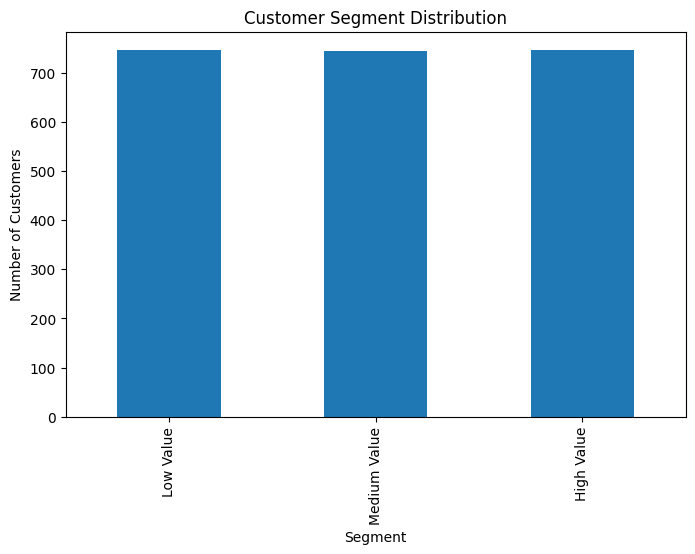

In [31]:
fig, ax = plt.subplots(figsize=(8,5))

segment_counts = (
    df["Customer_Segment"]
    .value_counts()
    .reindex(["Low Value", "Medium Value", "High Value"])
)

segment_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Customer Segment Distribution")
ax.set_xlabel("Segment")
ax.set_ylabel("Number of Customers")

fig.savefig(
    "customer_segment_distribution.png",
    bbox_inches="tight"
)

plt.show()

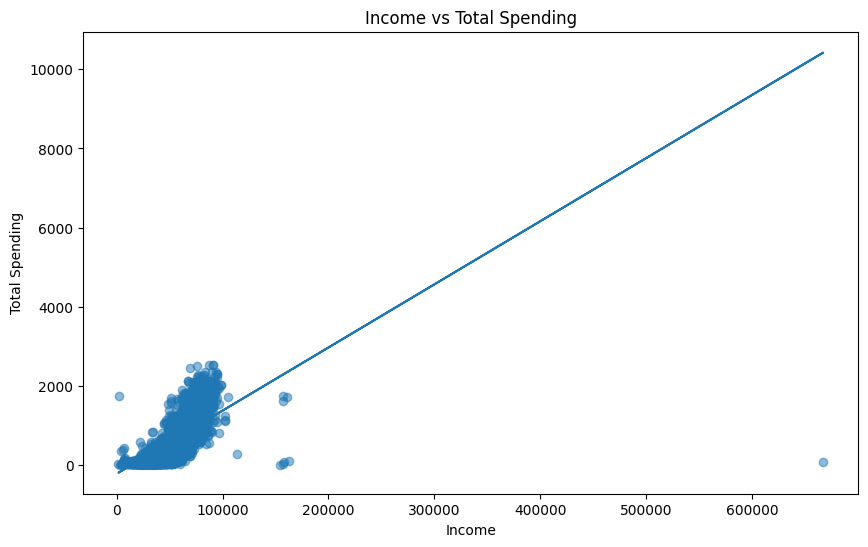

In [34]:

import numpy as np

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(
    df["Income"],
    df["Total_Spent"],
    alpha=0.5
)

# 趋势线
z = np.polyfit(
    df["Income"],
    df["Total_Spent"],
    1
)

p = np.poly1d(z)

ax.plot(
    df["Income"],
    p(df["Income"])
)

ax.set_title("Income vs Total Spending")
ax.set_xlabel("Income")
ax.set_ylabel("Total Spending")

fig.savefig(
    "images/income_vs_spending.png",
    bbox_inches="tight"
)

plt.show()

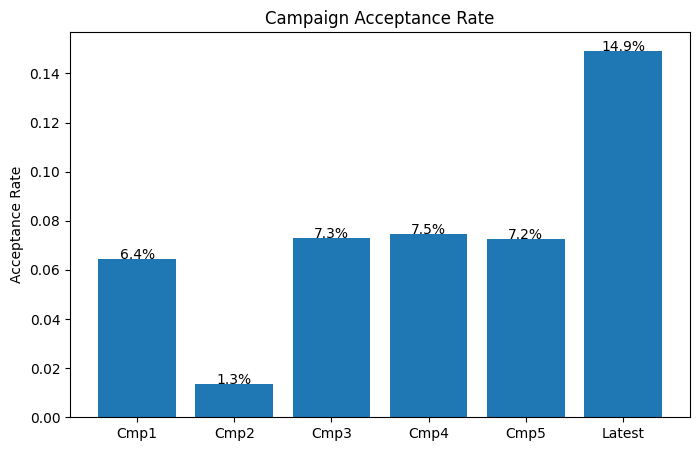

In [35]:
campaign_rates = {
    "Cmp1": df["AcceptedCmp1"].mean(),
    "Cmp2": df["AcceptedCmp2"].mean(),
    "Cmp3": df["AcceptedCmp3"].mean(),
    "Cmp4": df["AcceptedCmp4"].mean(),
    "Cmp5": df["AcceptedCmp5"].mean(),
    "Latest": df["Response"].mean()
}

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    campaign_rates.keys(),
    campaign_rates.values()
)

ax.set_title("Campaign Acceptance Rate")
ax.set_ylabel("Acceptance Rate")

# 显示数值标签
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1%}",
        ha="center"
    )

fig.savefig(
    "images/campaign_acceptance_rate.png",
    bbox_inches="tight"
)

plt.show()

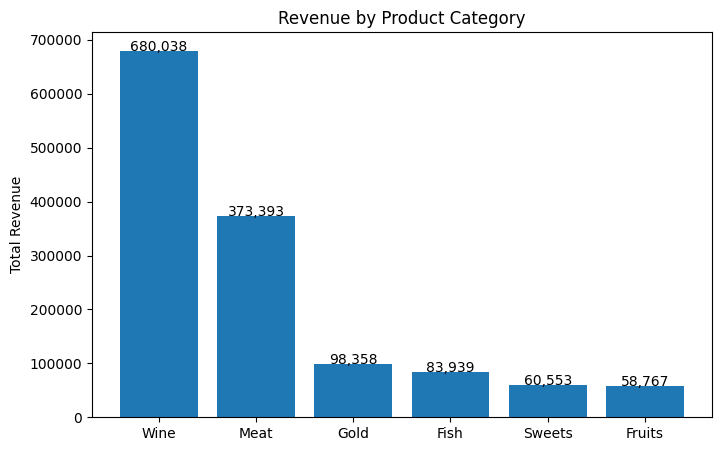

In [36]:
product_spending = {
    "Wine": df["MntWines"].sum(),
    "Meat": df["MntMeatProducts"].sum(),
    "Gold": df["MntGoldProds"].sum(),
    "Fish": df["MntFishProducts"].sum(),
    "Sweets": df["MntSweetProducts"].sum(),
    "Fruits": df["MntFruits"].sum()
}

# 按金额排序
product_spending = dict(
    sorted(
        product_spending.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    product_spending.keys(),
    product_spending.values()
)

ax.set_title("Revenue by Product Category")
ax.set_ylabel("Total Revenue")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center"
    )

fig.savefig(
    "images/product_category_revenue.png",
    bbox_inches="tight"
)

plt.show()